In [4]:
import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

In [5]:
import sys
sys.path.append("/mmhome/boittier/home/mmml")

import ase 
from ase import io
from ase.visualize import view
from pathlib import Path
import matplotlib.pyplot as plt

import sys
sys.path.append("/mmhome/boittier/home/mmml")

import mmml
import ase
import numpy as np
from ase import io
from ase.constraints import FixInternals
from ase.optimize import BFGS
from mmml.models.EF.ase_calc_EF import AseCalculatorEF

from mmml.interfaces.chemcoordInterface.interface import patch_chemcoord_for_pandas3

patch_chemcoord_for_pandas3()

import ase
from ase import io as ase_io
from ase.visualize import view
import pandas as pd
from sklearn.preprocessing import StandardScaler
import seaborn as sns


import chemcoord as cc

In [38]:
import jax
jax.devices()

[CudaDevice(id=0), CudaDevice(id=1)]

In [19]:
mol = ase.io.read("md_500_slice.traj")
CONFIG= "/mmhome/boittier/home/ckpts/dipeptide_ef2_ptF_run1/config.json"
PARAMS ="/mmhome/boittier/home/ckpts/dipeptide_ef2_ptF_run1/params.json"

EF = np.array([0,0,0])

calc = AseCalculatorEF(
    PARAMS,
    config_path=CONFIG,
    electric_field=EF,  # optional default field (model input units)
    field_scale=100,  # E_physical [au] = E_input * field_scale
)
print(calc)

In [20]:
R = mol.get_positions()
R

array([[ -1.43529959,  -6.09432312,  -9.82657237],
       [ -0.50184902,  -5.06173281, -10.71329045],
       [ -0.83736562,  -4.77763055, -11.96032316],
       [ -0.13325965,  -3.6661945 , -12.69128992],
       [ -2.22416317,  -5.17276102, -12.35401243],
       [  0.80573913,  -4.36693877,  -9.98159355],
       [  0.11907339,  -3.45479052,  -8.9411757 ],
       [  1.10021094,  -3.58522308,  -7.7426182 ],
       [  1.52484567,  -5.01453954,  -7.69809393],
       [  1.55987408,  -5.36929707,  -9.20552412],
       [  2.11020558,  -6.4369043 ,  -9.77245096],
       [  2.23346522,  -6.64850448, -11.43947067],
       [  2.80143533,  -7.34489065,  -8.86038412],
       [ -0.40690916,  -3.74059276, -13.75340066],
       [ -0.37064853,  -2.69557994, -12.36563133],
       [  0.95818558,  -3.83536214, -12.59576249],
       [ -2.33214444,  -4.91564323, -13.40107875],
       [ -2.98583491,  -4.68684864, -11.70260145],
       [ -2.36926918,  -6.30410672, -12.26428601],
       [  1.41165448,  -3.90518

In [39]:
mol.calc = calc

R = mol.get_positions()

R = R - R.mean(axis=0)
mol.set_positions(R)

In [40]:
R

array([[ 0.46155308,  2.03089144, -1.22399483],
       [-0.13471598,  0.50004323, -1.16808295],
       [-0.85943611, -0.08061064, -2.18252109],
       [-1.42681791, -1.42312141, -2.08371762],
       [-1.29187073,  0.73102273, -3.32270551],
       [ 0.29123607, -0.4490995 , -0.01711939],
       [ 1.78006203, -0.88787635, -0.18222593],
       [ 2.39645732, -0.63320227,  1.18909272],
       [ 1.56824855,  0.45652609,  1.82363993],
       [ 0.22200658,  0.18801477,  1.27566475],
       [-0.93826381,  0.49427131,  1.88877729],
       [-2.37949466,  0.07658625,  1.20649002],
       [-0.90966438,  1.15587932,  3.2477113 ],
       [-1.89491568, -1.68508906, -3.03007765],
       [-0.69914105, -2.17306439, -1.8349585 ],
       [-2.12531291, -1.46519193, -1.25789888],
       [-0.84785735,  0.3765696 , -4.26128709],
       [-0.89873281,  1.72147993, -3.10578656],
       [-2.3983613 ,  0.78073157, -3.47363136],
       [-0.27255656, -1.39103345,  0.01779796],
       [ 1.71453456, -1.93467056, -0.486

In [41]:
view(mol, viewer="x3d")

In [42]:
import numpy as np
from ase import Atoms, units
from ase.io import read
from ase.io.trajectory import Trajectory
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution
# from ase.md.langevin import Langevin
from ase.md.verlet import VelocityVerlet  # for NVE


from ase.optimize import FIRE
opt = FIRE(mol, maxstep=0.04)
opt.run(fmax=0.05, steps=500)




print(mol.get_potential_energy(), "eV")
print(np.max(np.abs(mol.get_forces())), "eV/Å")


      Step     Time          Energy          fmax
FIRE:    0 12:14:03     -130.213028        1.915838
FIRE:    1 12:14:04     -130.331650        0.633774
FIRE:    2 12:14:04     -130.377747        0.779865
FIRE:    3 12:14:04     -130.388779        0.576982
FIRE:    4 12:14:04     -130.404388        0.435477
FIRE:    5 12:14:04     -130.420654        0.424193
FIRE:    6 12:14:04     -130.439819        0.476877
FIRE:    7 12:14:04     -130.443436        0.580963
FIRE:    8 12:14:04     -130.465057        0.478461
FIRE:    9 12:14:04     -130.485596        0.296198
FIRE:   10 12:14:04     -130.498672        0.285791
FIRE:   11 12:14:04     -130.517853        0.466097
FIRE:   12 12:14:04     -130.525681        0.365086
FIRE:   13 12:14:04     -130.528793        0.348598
FIRE:   14 12:14:04     -130.530960        0.360054
FIRE:   15 12:14:04     -130.523438        0.295009
FIRE:   16 12:14:04     -130.534042        0.202008
FIRE:   17 12:14:04     -130.540207        0.155956
FIRE:   18 12:

In [43]:
view(mol, viewer="x3d")

In [44]:
# Velocities + thermostat
T_K = 300.0
dt_fs = 0.25
MaxwellBoltzmannDistribution(mol, temperature_K=T_K, rng=np.random.default_rng(42))
# dyn = Langevin(
#     atoms,
#     timestep=dt_fs * units.fs,
#     temperature_K=T_K,
#     friction=0.01 / units.fs,   # 1/fs
# )
dyn = VelocityVerlet(mol, timestep=dt_fs * units.fs)  # NVE
traj = Trajectory("md01.traj", "w", mol)
dyn.attach(traj.write, interval=1)
dyn.run(800_000)
traj.close()

In [45]:
traj = ase.io.read("md01.traj", index=":")
Es = [_.get_potential_energy() for _ in traj]

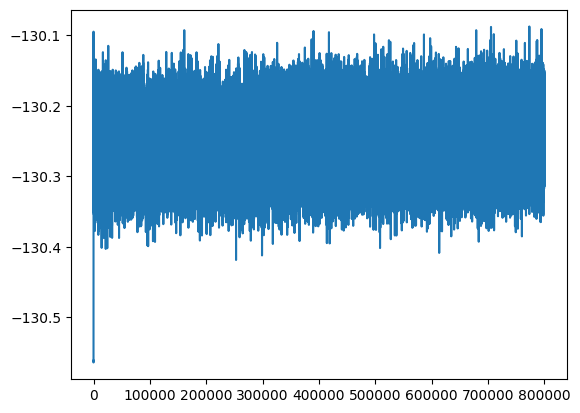

In [46]:
plt.plot(Es)

In [52]:
view(traj[-1], viewer="x3d")

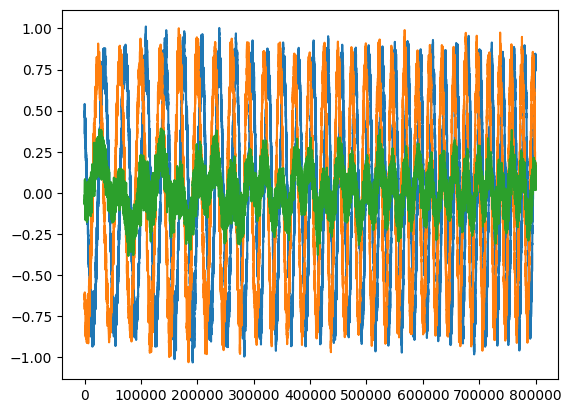

In [48]:
Ds = [_.get_dipole_moment() for _ in traj]
plt.plot(Ds)

In [49]:
import numpy as np
import ase.io
from pathlib import Path
import sys


from mmml.spectra import (
    extract_properties, compute_magnetic_dipoles,
    autocorrelation, cross_correlation, correlation_to_spectrum,
    compute_polarizability_batched, polarizability_autocorrelation,
    raman_to_spectrum,
)


dt_fs = .250  # 0.5 fs * write interval 10
pos, vel, mu, q = extract_properties(
    traj, calc=calc,
    recompute_dipole=False,   # True if no ml_dipole in traj
    recompute_charges=True,  # True if no ml_charges (needed for VCD)
)
m = compute_magnetic_dipoles(pos, vel, q)
acf_mu = autocorrelation(mu)
ccf_vm = cross_correlation(mu, m)
freq, ir = correlation_to_spectrum(acf_mu, dt_fs)
_, vcd = correlation_to_spectrum(ccf_vm, dt_fs)

    GPU-batched property extraction (batch_size=32, T=800001) ...
      chunk 1/25001
      chunk 2500/25001
      chunk 5000/25001
      chunk 7500/25001
      chunk 10000/25001
      chunk 12500/25001
      chunk 15000/25001
      chunk 17500/25001
      chunk 20000/25001
      chunk 22500/25001
      chunk 25000/25001
      Done in 97.55 s


In [50]:
from mmml.spectra.spectra_md import _freq_mask

# Optional: limit frequency range (e.g. 800–1800 cm⁻¹)
mask = _freq_mask(freq, 400.0, 4000.0)
freq_p = freq[mask]
ir_p = ir[mask]
vcd_p = vcd[mask]
T = len(mu)
total_fs = (T - 1) * dt_fs
print(f"Trajectory: {T} frames, {total_fs/1000:.1f} ps")

Trajectory: 800001 frames, 200.0 ps


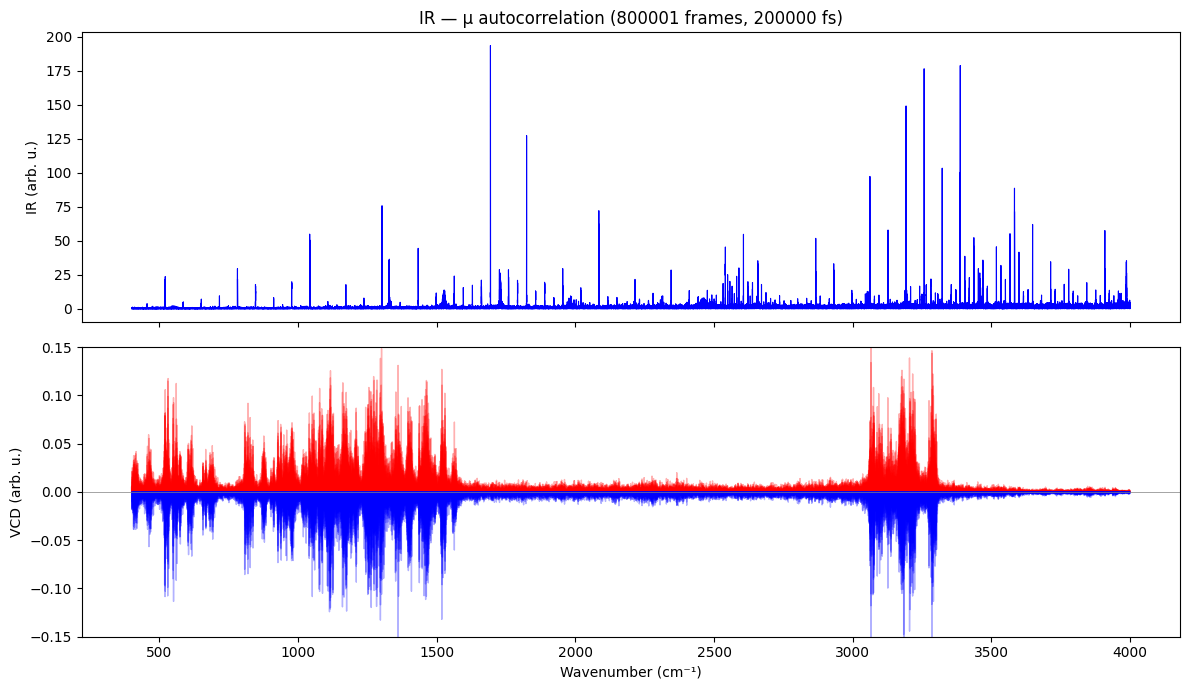

In [55]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
ax1.plot(freq_p, abs(ir_p), "b-", lw=0.8)
ax1.fill_between(freq_p, abs(ir_p), alpha=0.25)
ax1.set_ylabel("IR (arb. u.)")
ax1.set_title(f"IR — μ autocorrelation ({T} frames, {total_fs:.0f} fs)")
ax1.invert_xaxis()
# ax2.plot(freq_p, vcd_p, "k-", lw=0.8)
ax2.fill_between(freq_p, 0, vcd_p, where=(vcd_p >= 0), color="red", alpha=0.3)
ax2.fill_between(freq_p, 0, vcd_p, where=(vcd_p < 0), color="blue", alpha=0.3)
ax2.axhline(0, color="grey", lw=0.5)
ax2.set_ylabel("VCD (arb. u.)")
ax2.set_xlabel("Wavenumber (cm⁻¹)")
ax2.set_ylim(-0.15, 0.15)
ax2.invert_xaxis()
plt.tight_layout()
plt.show()

In [77]:
import h5py
mode="r"
f = h5py.File("/mmhome/boittier/home/mmml_tutorial/acodcm/output/dcm90.18.0/vac_nvt_jaxmd_nvt.h5", mode)

In [84]:
np.linalg.norm(np.array(f["positions"]).mean(axis=(1)),axis=-1)

array([0.11389855, 0.11156485, 0.11110931, 0.1120009 , 0.11303743,
       0.11334782, 0.11362702, 0.11447824, 0.11474779, 0.11385816,
       0.11199977, 0.11051485, 0.11011852, 0.10958123, 0.10929859,
       0.10945104, 0.11045694, 0.11218331, 0.11393286, 0.11517768,
       0.11649666, 0.11705691, 0.11705688, 0.11707748, 0.11693467,
       0.11685418, 0.11658409, 0.11652566, 0.11692353, 0.11763728,
       0.11867166, 0.11983339, 0.12060731, 0.12066969, 0.1205712 ,
       0.12099636, 0.12143213, 0.12168971, 0.12181449, 0.12194713,
       0.12245643, 0.12312503, 0.12404844, 0.12498433, 0.12564799,
       0.12594254, 0.12566212, 0.12554452, 0.12547305, 0.12529658,
       0.1251892 , 0.12490629, 0.12564337, 0.12712795, 0.12904724,
       0.1304562 , 0.13088432, 0.13077964, 0.13038476, 0.13032682,
       0.12988262, 0.12850831, 0.12718882, 0.1271455 , 0.12841138,
       0.13020696, 0.13114782, 0.13096413, 0.13124506, 0.13259554,
       0.1344114 , 0.13530028, 0.13518578, 0.13546754, 0.13677

In [11]:
files_list = list(Path("/mmhome/boittier/home/mmml/ef_eval").glob("*/*/*npz"))

In [12]:
data_dict = {}
for f in files_list:
    _ = str(f)
    print(f)
    data_dict[_] = np.load(_, allow_pickle=True)

/mmhome/boittier/home/mmml/ef_eval/0ptFbothNoPert/rotaug_pert0/evaluation_output.npz
/mmhome/boittier/home/mmml/ef_eval/0ptFbothNoPert/rotaug_pert0p25/evaluation_output.npz
/mmhome/boittier/home/mmml/ef_eval/0ptFbothNoPert/rotaug_pert0p5/evaluation_output.npz
/mmhome/boittier/home/mmml/ef_eval/0ptFbothNoPert/rotaug_pert0p75/evaluation_output.npz
/mmhome/boittier/home/mmml/ef_eval/0ptFbothNoPert/rotaug_pert1/evaluation_output.npz
/mmhome/boittier/home/mmml/ef_eval/0ptTbothPert/rotaug_pert0/evaluation_output.npz
/mmhome/boittier/home/mmml/ef_eval/0ptTbothPert/rotaug_pert0p25/evaluation_output.npz
/mmhome/boittier/home/mmml/ef_eval/0ptTbothPert/rotaug_pert0p5/evaluation_output.npz
/mmhome/boittier/home/mmml/ef_eval/0ptTbothPert/rotaug_pert0p75/evaluation_output.npz
/mmhome/boittier/home/mmml/ef_eval/0ptTbothPert/rotaug_pert1/evaluation_output.npz
/mmhome/boittier/home/mmml/ef_eval/1ptFbothNoPert/rotaug_pert0/evaluation_output.npz
/mmhome/boittier/home/mmml/ef_eval/1ptFbothNoPert/rotaug_pe

In [13]:
test = data_dict["/mmhome/boittier/home/mmml/ef_eval/0ptFbothNoPert/rotaug_pert0/evaluation_output.npz"]
list(test.keys())

['energy_pred',
 'energy_targets',
 'force_pred',
 'force_targets',
 'dipole_pred',
 'dipole_targets',
 'metrics',
 'R',
 'Z',
 'E',
 'F',
 'D',
 'Ef']

(-2.0, 2.0)

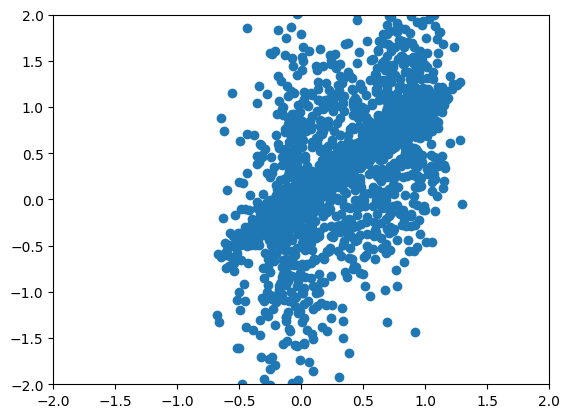

In [14]:
plt.scatter(test["dipole_pred"], test["dipole_targets"])
ax = plt.gca()
ax.set_xlim(-2, 2)
ax.set_ylim(-2, 2)

In [15]:
import re
import numpy as np
import pandas as pd
from pathlib import Path


def parse_eval_path(path):
    path = Path(path)
    
    # Example:
    # /.../ef_eval/0ptFbothNoPert/rotaug_pert0p25/evaluation_output.npz
    model_name = path.parts[-3]
    rotaug_name = path.parts[-2]

    # Parse point flag: 0pt or 1pt
    point_match = re.match(r"(?P<npt>[01])pt(?P<rest>.*)", model_name)
    npt = int(point_match.group("npt")) if point_match else None

    # Parse force perturbation flag
    # FbothNoPert vs TbothPert
    perturb_train = "bothPert" in model_name
    no_pert_train = "bothNoPert" in model_name

    # Parse rotation perturbation strength
    # rotaug_pert0p25 -> 0.25
    pert_str = rotaug_name.replace("rotaug_pert", "").replace("p", ".")
    rot_pert = float(pert_str)

    return {
        "path": str(path),
        "model": model_name,
        "npt": npt,
        "train_perturbed": perturb_train,
        "train_unperturbed": no_pert_train,
        "rotaug": rotaug_name,
        "rot_pert": rot_pert,
    }


def mae(x, y):
    return np.mean(np.abs(x - y))


def rmse(x, y):
    return np.sqrt(np.mean((x - y) ** 2))


def vector_mae(x, y):
    """
    For forces/dipoles: mean norm error per vector.
    Works for shapes like:
      forces: (n_frames, n_atoms, 3)
      dipoles: (n_frames, 3)
    """
    return np.mean(np.linalg.norm(x - y, axis=-1))


def vector_rmse(x, y):
    err2 = np.sum((x - y) ** 2, axis=-1)
    return np.sqrt(np.mean(err2))


def npz_to_row(path, data):
    row = parse_eval_path(path)

    # Scalars / direct prediction errors
    if "energy_pred" in data and "energy_targets" in data:
        row["energy_mae"] = mae(data["energy_pred"], data["energy_targets"])
        row["energy_rmse"] = rmse(data["energy_pred"], data["energy_targets"])

    if "force_pred" in data and "force_targets" in data:
        row["force_mae_component"] = mae(data["force_pred"], data["force_targets"])
        row["force_rmse_component"] = rmse(data["force_pred"], data["force_targets"])
        row["force_mae_vector"] = vector_mae(data["force_pred"], data["force_targets"])
        row["force_rmse_vector"] = vector_rmse(data["force_pred"], data["force_targets"])

    if "dipole_pred" in data and "dipole_targets" in data:
        row["dipole_mae_component"] = mae(data["dipole_pred"], data["dipole_targets"])
        row["dipole_rmse_component"] = rmse(data["dipole_pred"], data["dipole_targets"])
        row["dipole_mae_vector"] = vector_mae(data["dipole_pred"], data["dipole_targets"])
        row["dipole_rmse_vector"] = vector_rmse(data["dipole_pred"], data["dipole_targets"])

    # Expand metrics if stored as dict-like object
    if "metrics" in data:
        metrics = data["metrics"]

        # Often metrics in npz are saved as 0-d object arrays
        if isinstance(metrics, np.ndarray) and metrics.shape == ():
            metrics = metrics.item()

        if isinstance(metrics, dict):
            for k, v in metrics.items():
                try:
                    row[f"metric_{k}"] = float(v)
                except Exception:
                    row[f"metric_{k}"] = v

    return row


def build_eval_dataframe(results_dict):
    """
    results_dict:
        keys: filenames / paths
        values: np.load(...) objects, dict-like npz objects, or plain dicts
    """
    rows = []

    for path, data in results_dict.items():
        rows.append(npz_to_row(path, data))

    df = pd.DataFrame(rows)

    # Useful ordering
    sort_cols = ["npt", "train_perturbed", "rot_pert"]
    sort_cols = [c for c in sort_cols if c in df.columns]
    df = df.sort_values(sort_cols).reset_index(drop=True)

    return df

In [17]:
test_data

{'/mmhome/boittier/home/mmml/ef_eval/0ptFbothNoPert/rotaug_pert0/evaluation_output.npz': NpzFile '/mmhome/boittier/home/mmml/ef_eval/0ptFbothNoPert/rotaug_pert0/evaluation_output.npz' with keys: energy_pred, energy_targets, force_pred, force_targets, dipole_pred...,
 '/mmhome/boittier/home/mmml/ef_eval/0ptFbothNoPert/rotaug_pert0p25/evaluation_output.npz': NpzFile '/mmhome/boittier/home/mmml/ef_eval/0ptFbothNoPert/rotaug_pert0p25/evaluation_output.npz' with keys: energy_pred, energy_targets, force_pred, force_targets, dipole_pred...,
 '/mmhome/boittier/home/mmml/ef_eval/0ptFbothNoPert/rotaug_pert0p5/evaluation_output.npz': NpzFile '/mmhome/boittier/home/mmml/ef_eval/0ptFbothNoPert/rotaug_pert0p5/evaluation_output.npz' with keys: energy_pred, energy_targets, force_pred, force_targets, dipole_pred...,
 '/mmhome/boittier/home/mmml/ef_eval/0ptFbothNoPert/rotaug_pert0p75/evaluation_output.npz': NpzFile '/mmhome/boittier/home/mmml/ef_eval/0ptFbothNoPert/rotaug_pert0p75/evaluation_output.npz'

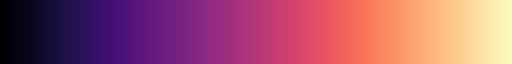

In [31]:
from matplotlib import cm
cm.magma

/mmhome/boittier/home/mmml/ef_eval/0ptFbothNoPert/rotaug_pert0/evaluation_output.npz
/mmhome/boittier/home/mmml/ef_eval/0ptFbothNoPert/rotaug_pert0p25/evaluation_output.npz
/mmhome/boittier/home/mmml/ef_eval/0ptFbothNoPert/rotaug_pert0p5/evaluation_output.npz
/mmhome/boittier/home/mmml/ef_eval/0ptFbothNoPert/rotaug_pert0p75/evaluation_output.npz
/mmhome/boittier/home/mmml/ef_eval/0ptFbothNoPert/rotaug_pert1/evaluation_output.npz
/mmhome/boittier/home/mmml/ef_eval/0ptFbothNoPert/rotaug_pert0/evaluation_output.npz
/mmhome/boittier/home/mmml/ef_eval/0ptFbothNoPert/rotaug_pert0p25/evaluation_output.npz
/mmhome/boittier/home/mmml/ef_eval/0ptFbothNoPert/rotaug_pert0p5/evaluation_output.npz
/mmhome/boittier/home/mmml/ef_eval/0ptFbothNoPert/rotaug_pert0p75/evaluation_output.npz
/mmhome/boittier/home/mmml/ef_eval/0ptFbothNoPert/rotaug_pert1/evaluation_output.npz
/mmhome/boittier/home/mmml/ef_eval/1ptFbothNoPert/rotaug_pert0/evaluation_output.npz
/mmhome/boittier/home/mmml/ef_eval/1ptFbothNoPert

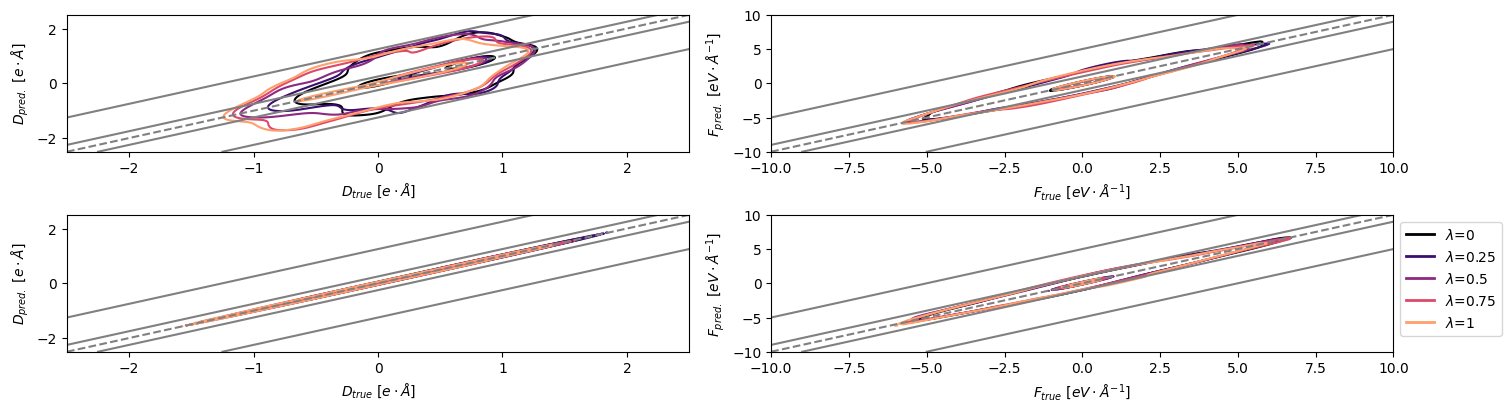

In [115]:
files_list = list(Path("/mmhome/boittier/home/mmml/ef_eval/0ptFbothNoPert").glob("*/*npz"))
files_list = list(Path("/mmhome/boittier/home/mmml/ef_eval/0ptTbothPert").glob("*/*npz"))
# files_list = list(Path("/mmhome/boittier/home/mmml/ef_eval/1ptTbothPert").glob("*/*npz"))
# files_list = list(Path("/mmhome/boittier/home/mmml/ef_eval/1ptFbothNoPert").glob("*/*npz"))
test_data = {}
for _ in files_list:
    test_data[str(_)] = np.load(_)


import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from matplotlib import cm

keys = list(test_data.keys())
n = len(keys)

fig, axes = plt.subplots(2, 2, figsize=(15, 4), constrained_layout=True)

def pert_label(k):
    return "$\\lambda$=" + k.split("/")[-2].split("pert")[-1].replace("p", ".")

legend_handles = [
    Line2D(
        [0], [0],
        color=cm.magma(i / n),
        label=pert_label(k),
        linewidth=2,
    )
    for i, k in enumerate(keys)
]

def add_reference_lines(ax):
    ax.plot([0, 1], [0, 1], c="gray", linestyle="--", transform=ax.transAxes)
    ax.plot([0.05, 1], [0, 0.95], c="gray", linestyle="-", transform=ax.transAxes)
    ax.plot([0, 0.95], [0.05, 1], c="gray", linestyle="-", transform=ax.transAxes)
    ax.plot([0.25, 1], [0, 0.75], c="gray", linestyle="-", transform=ax.transAxes)
    ax.plot([0, 0.75], [0.25, 1], c="gray", linestyle="-", transform=ax.transAxes)

def plot_kde_panel(test_data, ax, pred_key, target_key, title, xlim=None, ylim=None, stride=1):
    for i, k in enumerate(keys):
        print(k)
        test = test_data[k]

        x = test[pred_key].flatten()[::stride]
        y = test[target_key].flatten()[::stride]

        df_ = pd.DataFrame({"x": x, "y": y})

        sns.kdeplot(
            data=df_,
            x="x",
            y="y",
            levels=[0.15, 0.85],
            color=cm.magma(i / n),
            ax=ax,
        )
    if title:
        ax.set_title(title)
    ax.set_xlabel("prediction")
    ax.set_ylabel("target")

    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)

    add_reference_lines(ax)


files_list = list(Path("/mmhome/boittier/home/mmml/ef_eval/0ptFbothNoPert").glob("*/*npz"))
# files_list = list(Path("/mmhome/boittier/home/mmml/ef_eval/0ptTbothPert").glob("*/*npz"))
# files_list = list(Path("/mmhome/boittier/home/mmml/ef_eval/1ptTbothPert").glob("*/*npz"))
# files_list = list(Path("/mmhome/boittier/home/mmml/ef_eval/1ptFbothNoPert").glob("*/*npz"))
test_data = {}
for _ in files_list:
    test_data[str(_)] = np.load(_)
keys = list(test_data.keys())


plot_kde_panel(
    test_data,
    axes[0,0],
    pred_key="dipole_pred",
    target_key="dipole_targets",
    title=False,
    xlim=(-2.5, 2.5),
    ylim=(-2.5, 2.5),
)

plot_kde_panel(
    test_data,
    axes[0,1],
    pred_key="force_pred",
    target_key="force_targets",
    title=False,
    xlim=(-10, 10),
    ylim=(-10, 10),
    stride=50,
)

# files_list = list(Path("/mmhome/boittier/home/mmml/ef_eval/0ptFbothNoPert").glob("*/*npz"))
# files_list = list(Path("/mmhome/boittier/home/mmml/ef_eval/0ptTbothPert").glob("*/*npz"))
# files_list = list(Path("/mmhome/boittier/home/mmml/ef_eval/1ptTbothPert").glob("*/*npz"))
files_list = list(Path("/mmhome/boittier/home/mmml/ef_eval/1ptFbothNoPert").glob("*/*npz"))
test_data = {}
for _ in files_list:
    test_data[str(_)] = np.load(_)

keys = list(test_data.keys())

plot_kde_panel(
    test_data,
    axes[1,0],
    pred_key="dipole_pred",
    target_key="dipole_targets",
    title=False,
    xlim=(-2.5, 2.5),
    ylim=(-2.5, 2.5),
)

plot_kde_panel(
    test_data,
    axes[1,1],
    pred_key="force_pred",
    target_key="force_targets",
    title=False,
    xlim=(-10, 10),
    ylim=(-10, 10),
    stride=50,
)

# plot_kde_panel(
#     axes[2],
#     pred_key="energy_pred",
#     target_key="energy_targets",
#     title="Energy",
# )

dip_true_label = "$D_{true}~[e\\cdot\\AA]$"
dip_pred_label = "$D_{pred.}~[e\\cdot\\AA]$"
force_true_label = "$F_{true}~[{eV}\\cdot\\AA^{-1}]$"
force_pred_label = "$F_{pred.}~[{eV}\\cdot\\AA^{-1}]$"

axes[0,0].set_xlabel(dip_true_label)
axes[0,0].set_ylabel(dip_pred_label)
axes[0,1].set_xlabel(force_true_label)
axes[0,1].set_ylabel(force_pred_label)
axes[1,0].set_xlabel(dip_true_label)
axes[1,0].set_ylabel(dip_pred_label)
axes[1,1].set_xlabel(force_true_label)
axes[1,1].set_ylabel(force_pred_label)
plt.legend(handles=legend_handles, loc="best", bbox_to_anchor=(1,1))

plt.show()

In [90]:
plt.legend?

Signature: plt.legend(*args, **kwargs) -> 'Legend'
Docstring:
Place a legend on the Axes.

Call signatures::

    legend()
    legend(handles, labels)
    legend(handles=handles)
    legend(labels)

The call signatures correspond to the following different ways to use
this method:

**1. Automatic detection of elements to be shown in the legend**

The elements to be added to the legend are automatically determined,
when you do not pass in any extra arguments.

In this case, the labels are taken from the artist. You can specify
them either at artist creation or by calling the
:meth:`~.Artist.set_label` method on the artist::

    ax.plot([1, 2, 3], label='Inline label')
    ax.legend()

or::

    line, = ax.plot([1, 2, 3])
    line.set_label('Label via method')
    ax.legend()

.. note::
    Specific artists can be excluded from the automatic legend element
    selection by using a label starting with an underscore, "_".
    A string starting with an underscore is the default label for a

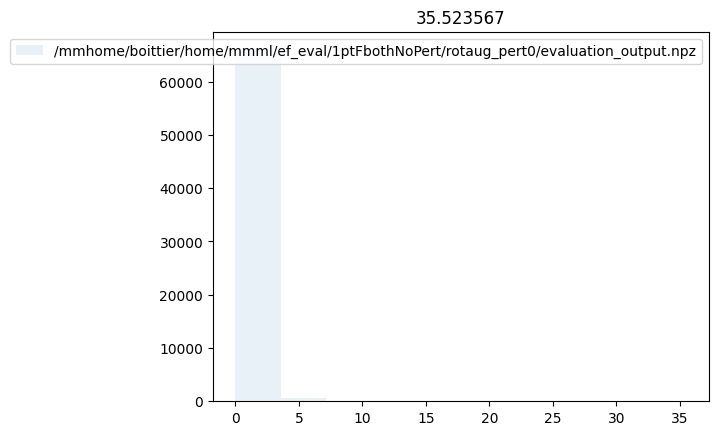

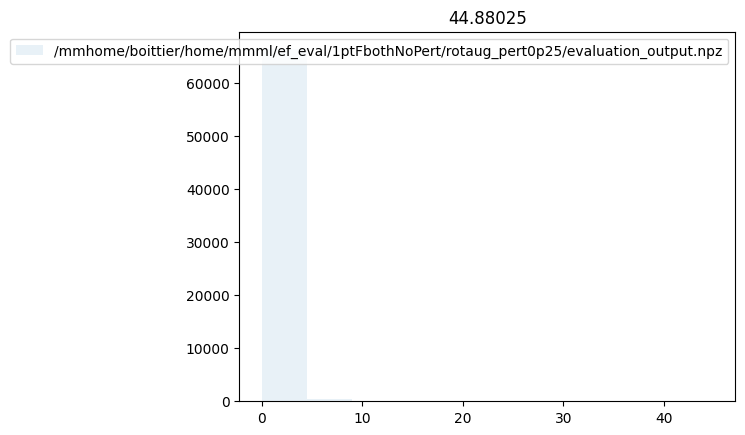

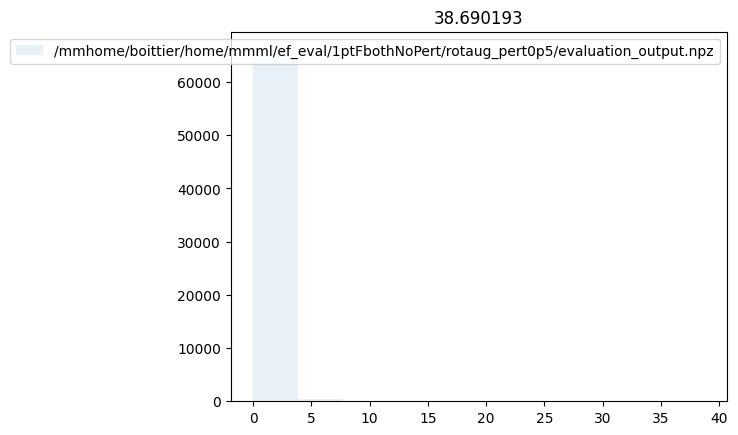

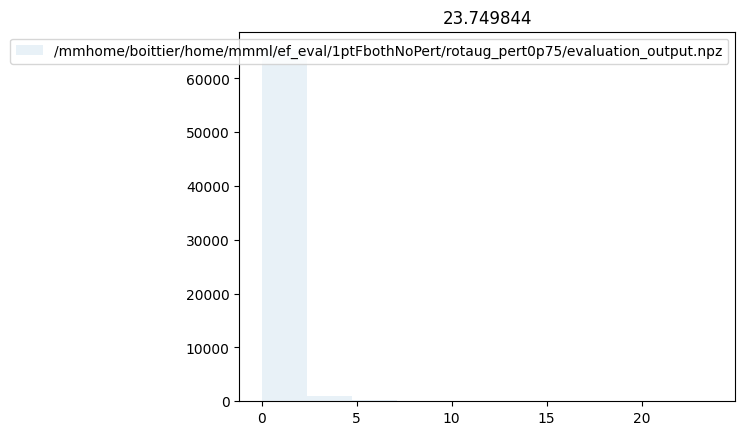

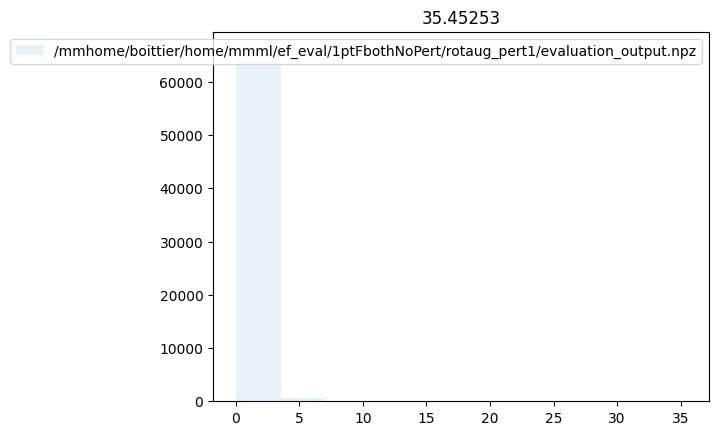

In [80]:
for k in list(test_data.keys()):

    test = test_data[k]
    plt.hist((test["force_pred"].flatten() - test["force_targets"].flatten())**2,alpha=0.1, label=str(k))
    ax = plt.gca()
    # ax.set_xlim(-2, 2)
    # ax.set_ylim(-2, 2)
    plt.title(np.max((test["force_pred"].flatten() - test["force_targets"].flatten())**2))
    plt.legend()
    plt.show()

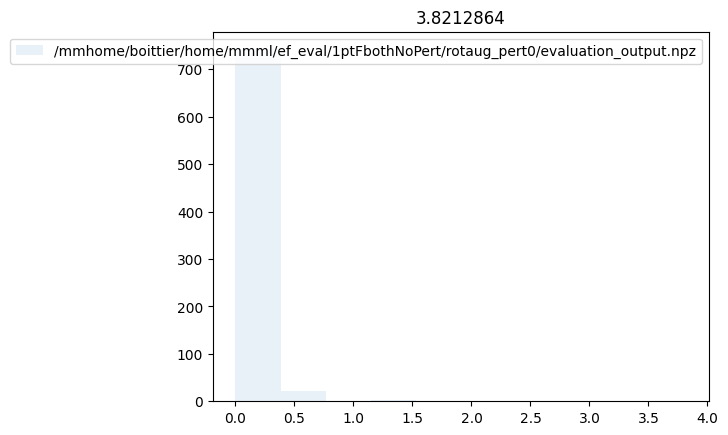

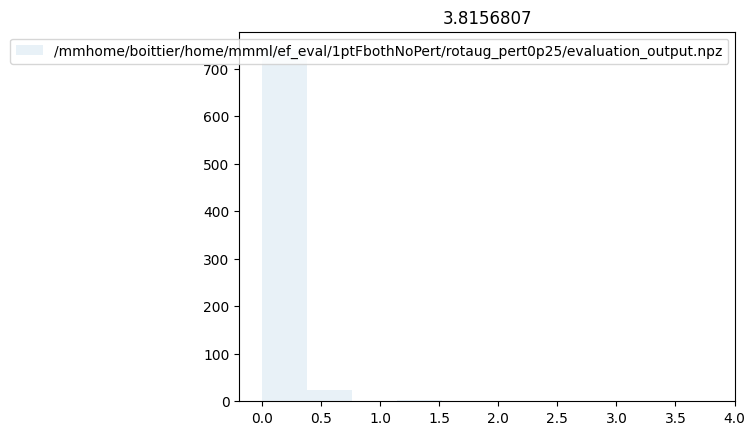

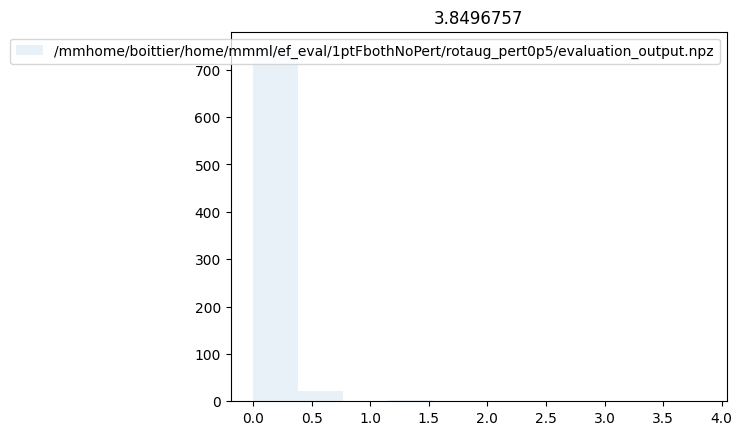

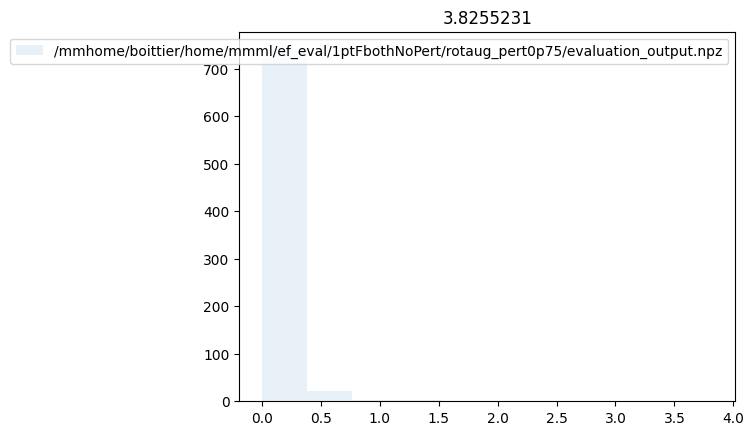

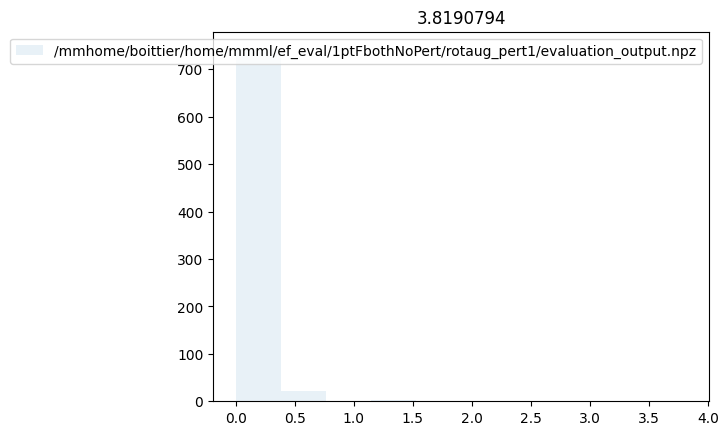

In [81]:
for k in list(test_data.keys()):

    test = test_data[k]
    plt.hist((test["energy_pred"].flatten() - test["energy_targets"].flatten())**2,alpha=0.1, label=str(k))
    ax = plt.gca()
    # ax.set_xlim(-2, 2)
    # ax.set_ylim(-2, 2)
    plt.title(np.max((test["energy_pred"].flatten() - test["energy_targets"].flatten())**2))
    plt.legend()
    plt.show()

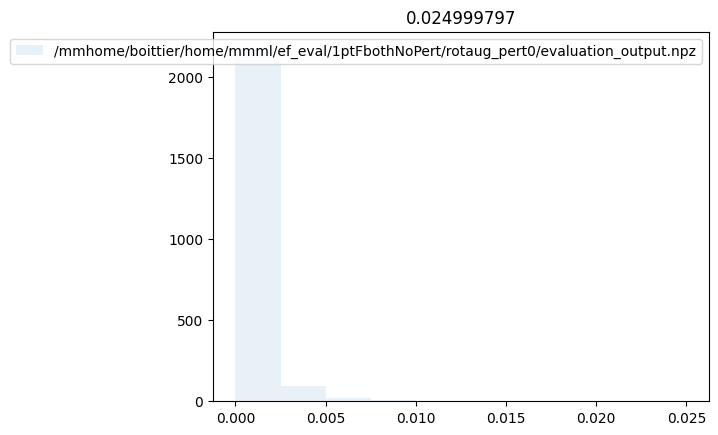

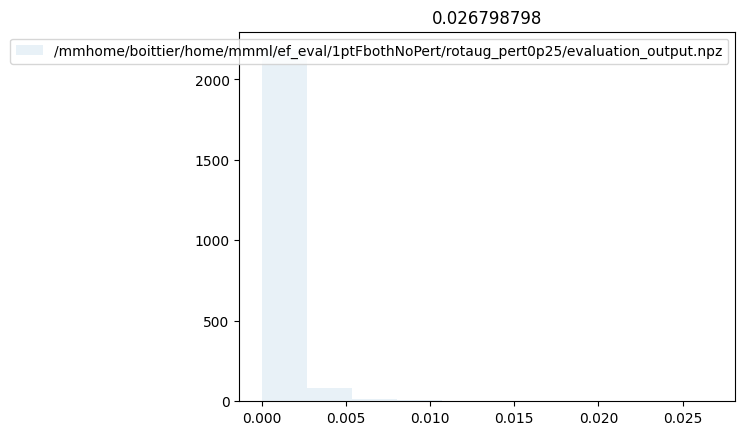

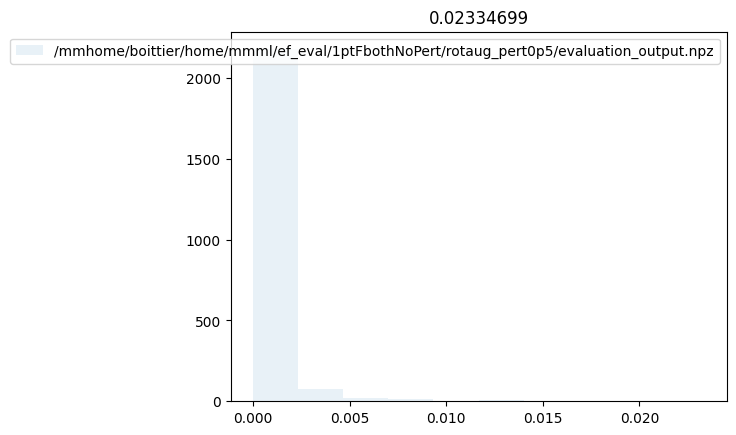

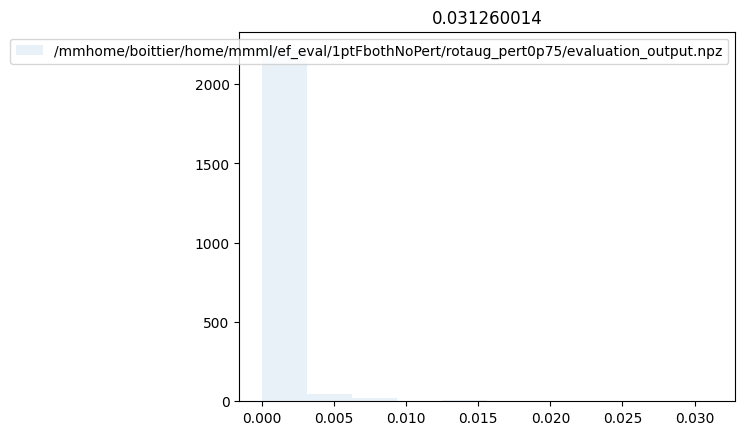

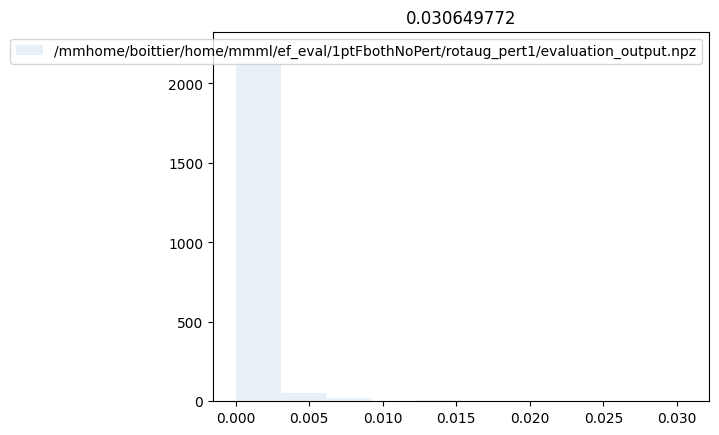

In [82]:
for k in list(test_data.keys()):

    test = test_data[k]
    plt.hist((test["dipole_pred"].flatten() - test["dipole_targets"].flatten())**2,alpha=0.1, label=str(k))
    ax = plt.gca()
    # ax.set_xlim(-2, 2)
    # ax.set_ylim(-2, 2)
    plt.title(np.max((test["dipole_pred"].flatten() - test["dipole_targets"].flatten())**2))
    plt.legend()
    plt.show()

(-2.0, 2.0)

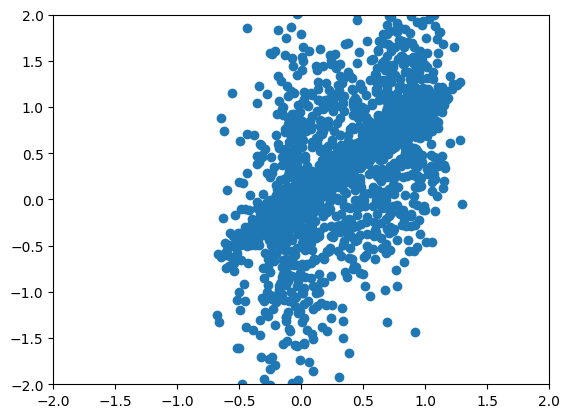

In [22]:
df = build_eval_dataframe(data_dict)
df[[""]]

,path,model,npt,train_perturbed,train_unperturbed,rotaug,rot_pert,energy_mae,energy_rmse,force_mae_component,...,metric_mae_magnitude_kcal_mol_ang,metric_rmse_magnitude_kcal_mol_ang,metric_r,metric_mae_overall_debye,metric_rmse_overall_debye,metric_mae_x_debye,metric_mae_y_debye,metric_mae_z_debye,metric_mae_magnitude_debye,metric_rmse_magnitude_debye
0,/mmhome/boittier/home/mmml/ef_eval/0ptFbothNoP...,0ptFbothNoPert,0,False,True,rotaug_pert0,0.00,0.446031,0.616038,0.530652,...,15.503032,24.237078,0.596155,0.358150,0.575799,0.353997,0.372223,0.348230,0.378221,0.613205
1,/mmhome/boittier/home/mmml/ef_eval/0ptFbothNoP...,0ptFbothNoPert,0,False,True,rotaug_pert0p25,0.25,0.446070,0.616094,0.531713,...,15.502977,24.237165,0.618069,0.357133,0.575801,0.359143,0.362669,0.349586,0.378223,0.613206
2,/mmhome/boittier/home/mmml/ef_eval/0ptFbothNoP...,0ptFbothNoPert,0,False,True,rotaug_pert0p5,0.50,0.446035,0.616044,0.531935,...,15.503106,24.237118,0.663455,0.352865,0.575799,0.356214,0.353211,0.349171,0.378217,0.613205
3,/mmhome/boittier/home/mmml/ef_eval/0ptFbothNoP...,0ptFbothNoPert,0,False,True,rotaug_pert0p75,0.75,0.446079,0.616076,0.531790,...,15.502985,24.237087,0.689874,0.353342,0.575796,0.357372,0.351809,0.350846,0.378218,0.613206
4,/mmhome/boittier/home/mmml/ef_eval/0ptFbothNoP...,0ptFbothNoPert,0,False,True,rotaug_pert1,1.00,0.446057,0.616080,0.531809,...,15.502894,24.236849,0.694044,0.355112,0.575800,0.359101,0.356287,0.349947,0.378221,0.613205
5,/mmhome/boittier/home/mmml/ef_eval/0ptTbothPer...,0ptTbothPert,0,True,False,rotaug_pert0,0.00,0.446339,0.609140,0.522242,...,15.161356,23.849607,0.598333,0.359484,0.574672,0.357170,0.373923,0.347360,0.377082,0.613472
6,/mmhome/boittier/home/mmml/ef_eval/0ptTbothPer...,0ptTbothPert,0,True,False,rotaug_pert0p25,0.25,0.446334,0.609171,0.522954,...,15.161427,23.849665,0.620120,0.358266,0.574671,0.362304,0.364392,0.348102,0.377084,0.613473
7,/mmhome/boittier/home/mmml/ef_eval/0ptTbothPer...,0ptTbothPert,0,True,False,rotaug_pert0p5,0.50,0.446312,0.609099,0.523408,...,15.161337,23.849504,0.665335,0.354107,0.574670,0.360763,0.356405,0.345151,0.377087,0.613476
8,/mmhome/boittier/home/mmml/ef_eval/0ptTbothPer...,0ptTbothPert,0,True,False,rotaug_pert0p75,0.75,0.446330,0.609161,0.523366,...,15.161418,23.849539,0.691528,0.355134,0.574671,0.361663,0.356201,0.347539,0.377081,0.613476
9,/mmhome/boittier/home/mmml/ef_eval/0ptTbothPer...,0ptTbothPert,0,True,False,rotaug_pert1,1.00,0.446314,0.609158,0.523515,...,15.161588,23.849833,0.695544,0.356144,0.574667,0.360067,0.358971,0.349395,0.377081,0.613475


In [25]:
list(df.keys())

['path',
 'model',
 'npt',
 'train_perturbed',
 'train_unperturbed',
 'rotaug',
 'rot_pert',
 'energy_mae',
 'energy_rmse',
 'force_mae_component',
 'force_rmse_component',
 'force_mae_vector',
 'force_rmse_vector',
 'dipole_mae_component',
 'dipole_rmse_component',
 'dipole_mae_vector',
 'dipole_rmse_vector',
 'metric_mae',
 'metric_rmse',
 'metric_r2',
 'metric_mean_error',
 'metric_std_error',
 'metric_max_abs_error',
 'metric_mae_kcal_mol',
 'metric_rmse_kcal_mol',
 'metric_mean_error_kcal_mol',
 'metric_std_error_kcal_mol',
 'metric_max_abs_error_kcal_mol',
 'metric_mae_overall',
 'metric_rmse_overall',
 'metric_r2_overall',
 'metric_r_overall',
 'metric_mae_x',
 'metric_mae_y',
 'metric_mae_z',
 'metric_r2_x',
 'metric_r2_y',
 'metric_r2_z',
 'metric_mae_components',
 'metric_mae_magnitude',
 'metric_rmse_magnitude',
 'metric_r2_magnitude',
 'metric_mae_overall_kcal_mol_ang',
 'metric_rmse_overall_kcal_mol_ang',
 'metric_mae_x_kcal_mol_ang',
 'metric_mae_y_kcal_mol_ang',
 'metric

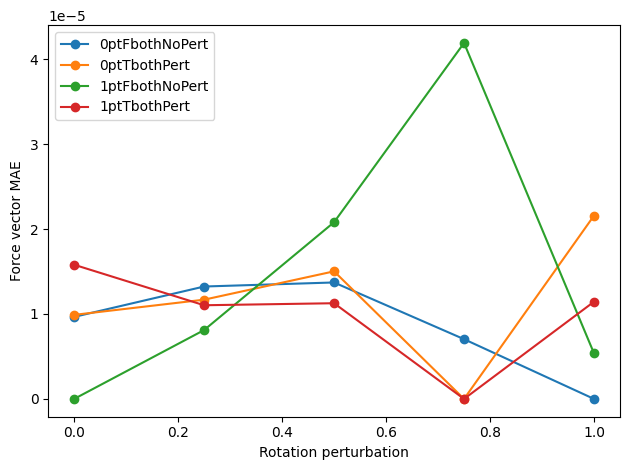

In [24]:
import matplotlib.pyplot as plt

for model, sub in df.groupby("model"):
    plt.plot(sub["rot_pert"], sub["force_mae_vector"], marker="o", label=model)

plt.xlabel("Rotation perturbation")
plt.ylabel("Force vector MAE")
plt.legend()
plt.tight_layout()
plt.show()